In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Montreal_UHI_toolbox import add_field_to_stations, add_blurred_field_to_stations, stations

# Two methods for comparing stations and observation:
    # 1. Smooth JJA tasmin/max/avg simulated fields, grab closest station
    # 2. Use multivariate regression sfc_scheme (MVRM) trained on station data to reproduce the simulation

In [3]:
# Load all summer data from observation and otherwise into stations dataset

summer = {}
summer_std = {}
path = '/runoff/gulley/St_Laurent/intermediates'
season = 'JJA'
for field in ['tasmin','tasmax','tasavg']:

    # Loading simulated summer averages 
    summer[f'{field}_C'] = xr.open_zarr(f'{path}/sim/seasons_avg_{field}_noTEB.zarr')[field].sel(season='JJA') - 273.15
    summer[f'{field}_T'] = xr.open_zarr(f'{path}/sim/seasons_avg_{field}_TEB.zarr')[field].sel(season='JJA') - 273.15

    # Loading simulated summer standard deviations
    summer_std[f'{field}_C'] = xr.open_zarr(f'{path}/sim/seasons_std_{field}_noTEB.zarr')[field].sel(season='JJA')
    summer_std[f'{field}_T'] = xr.open_zarr(f'{path}/sim/seasons_std_{field}_TEB.zarr')[field].sel(season='JJA')

    
    # Adding smoothed simulated summer averages to nearest station
    stations = add_blurred_field_to_stations(summer[f'{field}_C'],stations=stations,name=f'{field}_summer_avg_C')
    stations = add_blurred_field_to_stations(summer[f'{field}_T'],stations=stations,name=f'{field}_summer_avg_T')

    # Adding smoothed summer standard deviation to nearest station
    stations = add_blurred_field_to_stations(summer_std[f'{field}_C'],stations=stations,name=f'{field}_summer_std_C')
    stations = add_blurred_field_to_stations(summer_std[f'{field}_T'],stations=stations,name=f'{field}_summer_std_T')

# Loading station summer averages
tasmax_S = xr.open_zarr(f'{path}/station/seasons_avg_tasmax.zarr')['tasmax'].sel(season=season)
tasmin_S = xr.open_zarr(f'{path}/station/seasons_avg_tasmin.zarr')['tasmin'].sel(season=season)
tasavg_S = xr.open_zarr(f'{path}/station/seasons_avg_tas.zarr')['tas'].sel(season=season).rename('tasavg')
# Loading station summer standard deviations
tasmax_std_S = xr.open_zarr(f'{path}/station/seasons_std_tasmax.zarr')['tasmax'].sel(season=season)
tasmin_std_S = xr.open_zarr(f'{path}/station/seasons_std_tasmin.zarr')['tasmin'].sel(season=season)
tasavg_std_S = xr.open_zarr(f'{path}/station/seasons_std_tas.zarr')['tas'].sel(season=season).rename('tasavg')


for da in [tasmax_S,tasmin_S,tasavg_S]:
    stations[f'{da.name}_summer_avg_S'] = da

for da in [tasmax_std_S,tasmin_std_S,tasavg_std_S]:
    stations[f'{da.name}_summer_std_S'] = da

stations = stations.dropna(dim="station", subset=['tasmax_summer_avg_S','tasmin_summer_avg_S','tasmin_summer_avg_S'])

In [4]:
sfc_schemes = ['C','T']
for field in ['tasmin','tasmax','tasavg']:
    for sfc_scheme in sfc_schemes:
        # Subtract observed values from modelled values of summer averages
        stations[f'{field}_summer_avg_obsDiff_{sfc_scheme}'] = stations[f'{field}_summer_avg_{sfc_scheme}'] - stations[f'{field}_summer_avg_S']

        # Differences in summertime variability
        stations[f'{field}_summer_std_obsDiff_{sfc_scheme}'] = stations[f'{field}_summer_std_{sfc_scheme}'] - stations[f'{field}_summer_std_S']

In [5]:
stations

<xarray.Dataset> Size: 73MB
Dimensions:                        (station: 45, time: 67145)
Coordinates: (12/23)
  * station                        (station) object 360B '6101874' ... '7077570'
  * time                           (time) datetime64[ns] 537kB 1840-03-01 ......
    stnid                          (station) object 360B '6101874' ... '7077570'
    station_name                   (station) object 360B 'CORNWALL' ... 'ST M...
    lon                            (station) float64 360B -74.75 ... -73.92
    lat                            (station) float64 360B 45.02 44.92 ... 46.68
    ...                             ...
    tasavg_summer_avg_T            (station) float64 360B 22.16 21.59 ... 18.7
    tasavg_summer_std_C            (station) float64 360B 3.857 3.763 ... 4.144
    tasavg_summer_std_T            (station) float64 360B 3.849 3.787 ... 4.148
    lake_fraction                  (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    season                         <U3 12B 'JJA'
    urban_fraction                 (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
Data variables: (12/30)
    elev                           (station) float64 360B ...
    prov                           (station) object 360B ...
    fromyear                       (station) float64 360B ...
    frommonth                      (station) float64 360B ...
    toyear                         (station) float64 360B ...
    tomonth                        (station) float64 360B ...
    ...                             ...
    tasmax_summer_avg_obsDiff_T    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasmax_summer_std_obsDiff_T    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasavg_summer_avg_obsDiff_C    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasavg_summer_std_obsDiff_C    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasavg_summer_avg_obsDiff_T    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasavg_summer_std_obsDiff_T    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
Attributes: (12/14)
    title:                Third Generation of Homogenized Daily Temperature f...
    history:              2024-06-11 : Convert from original format to NetCDF
    type:                 station_obs
    institute:            Environment and Climate Change Canada
    institute_id:         ECCC
    dataset_id:           AHCCD_gen3_day_temperature
    ...                   ...
    abstract:             Adjusted and Homogenized Canadian Climate Data (AHC...
    dataset_description:  https://crd-data-donnees-rdc.ec.gc.ca/CDAS/products...
    license_type:         permissive
    license:              https:/open.canada.ca/en/open-government-licence-ca...
    DODS.strlen:          1
    DODS.dimName:         string1

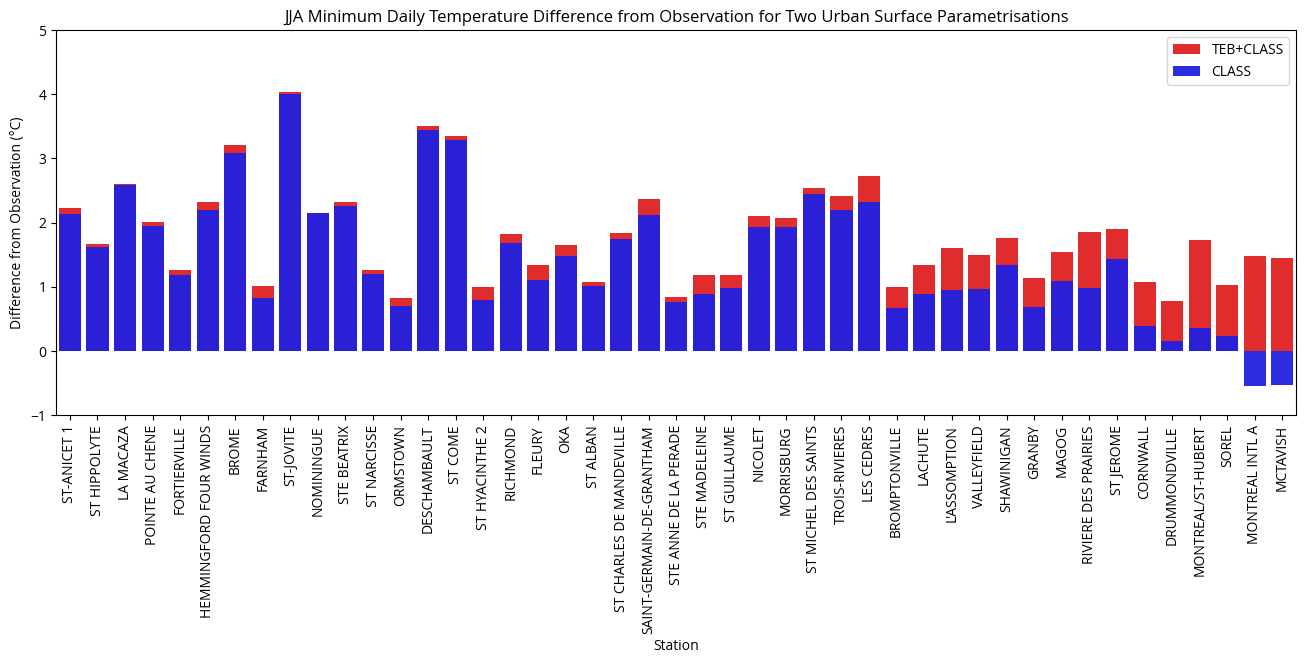

In [52]:
# plt.figure(figsize=(8, 4))
ordered_stations = stations.sortby('urban_fraction_blurred_std1p5')
fig,ax = plt.subplots(figsize=(16,5))

ax.tick_params(axis='x', labelrotation=90)

bar_plot = sns.barplot(x='station_name', y='tasmin_summer_avg_obsDiff_T', data=ordered_stations,label='TEB+CLASS',color='red',alpha=0.95)
bar_plot = sns.barplot(x='station_name', y='tasmin_summer_avg_obsDiff_C', data=ordered_stations,label='CLASS',color='blue',alpha=0.95)
plt.title('JJA Minimum Daily Temperature Difference from Observation for Two Urban Surface Parametrisations')
plt.xlabel('Station')
plt.ylabel('Difference from Observation (°C)')
plt.ylim([-1,5])

plt.show()

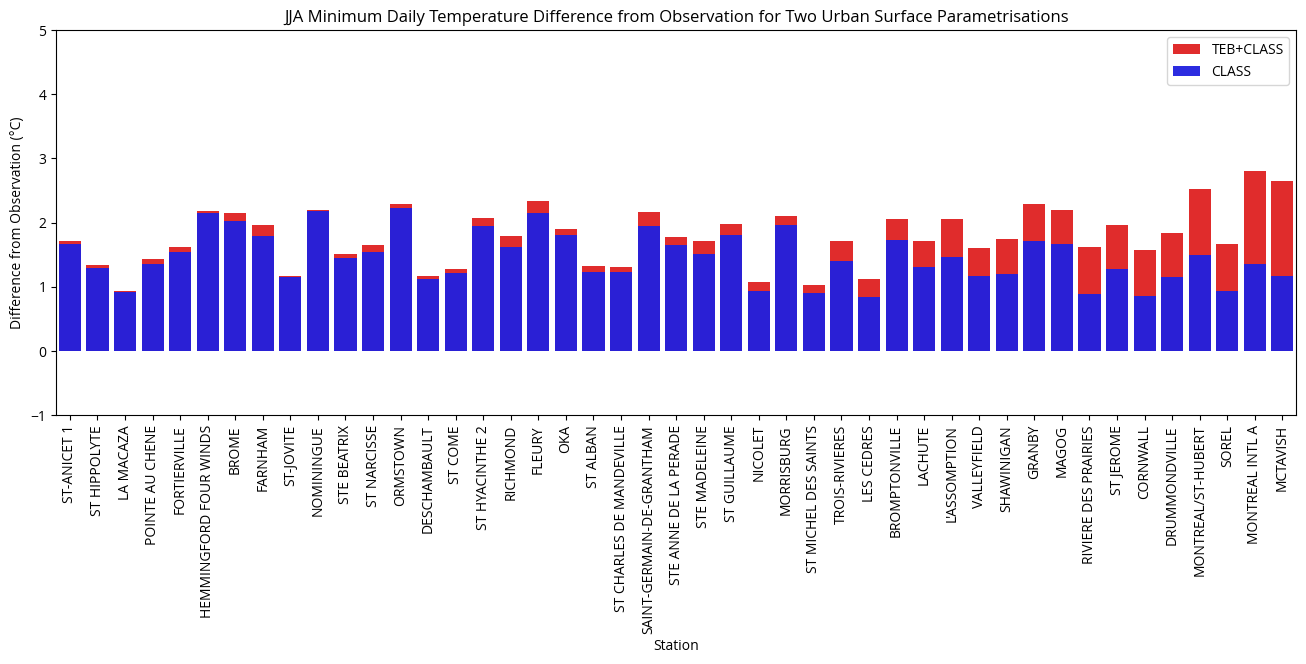

In [53]:
ordered_stations = stations.sortby('urban_fraction_blurred_std1p5')
fig,ax = plt.subplots(figsize=(16,5))
ax.tick_params(axis='x', labelrotation=90)
bar_plot = sns.barplot(x='station_name', y='tasmax_summer_avg_obsDiff_T', data=ordered_stations,label='TEB+CLASS',color='red',alpha=0.95)
bar_plot = sns.barplot(x='station_name', y='tasmax_summer_avg_obsDiff_C', data=ordered_stations,label='CLASS',color='blue',alpha=0.95)
plt.title('JJA Minimum Daily Temperature Difference from Observation for Two Urban Surface Parametrisations')
plt.xlabel('Station')
plt.ylabel('Difference from Observation (°C)')
plt.ylim([-1,5])
plt.show()

In [20]:
# Sort stations by descending urban fraction
ordered_stations = stations.sortby('urban_fraction_blurred_std1p5', ascending=False)

# # Plot
# plt.figure(figsize=(16, 5))
# sns.barplot(
#     x="station_name", y="diff", hue="scheme", 
#     data=df_long, order=order
# )
# plt.xticks(rotation=90)
# plt.title("JJA Minimum Daily Temperature Difference from Observation for Two Surface Schemes")
# plt.xlabel("Station (sorted by urban fraction)")
# plt.ylabel("Difference from Observation (°C)")
# plt.legend(title="Surface Scheme")
# plt.tight_layout()
# plt.show()


In [21]:
ordered

<xarray.Dataset> Size: 73MB
Dimensions:                        (station: 45, time: 67145)
Coordinates: (12/23)
  * station                        (station) object 360B '7024745' ... '702FQLF'
  * time                           (time) datetime64[ns] 537kB 1840-03-01 ......
    stnid                          (station) object 360B '7024745' ... '702FQLF'
    station_name                   (station) object 360B 'MCTAVISH' ... 'ST-A...
    lon                            (station) float64 360B -73.58 ... -74.28
    lat                            (station) float64 360B 45.5 45.47 ... 45.12
    ...                             ...
    tasavg_summer_avg_T            (station) float64 360B 22.78 22.75 ... 21.57
    tasavg_summer_std_C            (station) float64 360B 4.077 4.03 ... 3.968
    tasavg_summer_std_T            (station) float64 360B 4.036 4.003 ... 3.965
    lake_fraction                  (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    season                         <U3 12B 'JJA'
    urban_fraction                 (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
Data variables: (12/30)
    elev                           (station) float64 360B ...
    prov                           (station) object 360B ...
    fromyear                       (station) float64 360B ...
    frommonth                      (station) float64 360B ...
    toyear                         (station) float64 360B ...
    tomonth                        (station) float64 360B ...
    ...                             ...
    tasmax_summer_avg_obsDiff_T    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasmax_summer_std_obsDiff_T    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasavg_summer_avg_obsDiff_C    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasavg_summer_std_obsDiff_C    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasavg_summer_avg_obsDiff_T    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    tasavg_summer_std_obsDiff_T    (station) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
Attributes: (12/14)
    title:                Third Generation of Homogenized Daily Temperature f...
    history:              2024-06-11 : Convert from original format to NetCDF
    type:                 station_obs
    institute:            Environment and Climate Change Canada
    institute_id:         ECCC
    dataset_id:           AHCCD_gen3_day_temperature
    ...                   ...
    abstract:             Adjusted and Homogenized Canadian Climate Data (AHC...
    dataset_description:  https://crd-data-donnees-rdc.ec.gc.ca/CDAS/products...
    license_type:         permissive
    license:              https:/open.canada.ca/en/open-government-licence-ca...
    DODS.strlen:          1
    DODS.dimName:         string1